# Q learning

Début de l'entraînement...
Evaluation: Mean Reward = -23240.56 +- 0.00
Evaluation: Mean Reward = -23240.56 +- 0.00


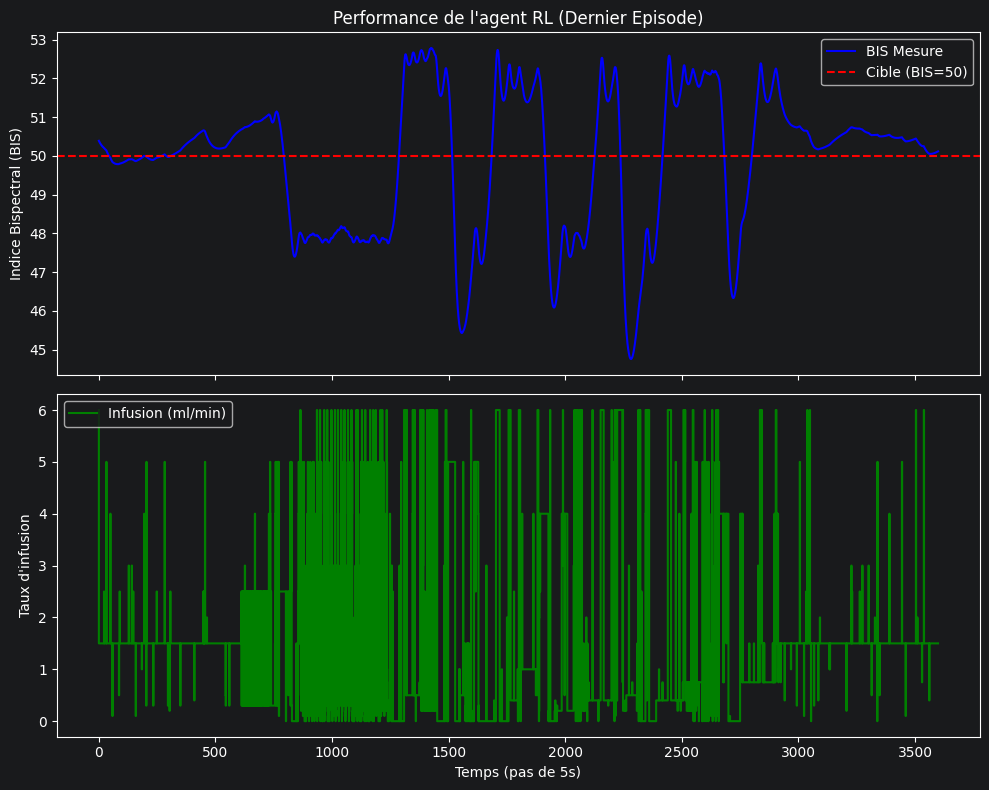

In [2]:
import numpy as np
from utils.rl_visualization import plot_simple_episode

# --- CONFIGURATION PK/PD (Modèle de Schnider & Doufas) ---

def evaluate_q_policy(env, q_table, episodes=10, steps=1200):
    rewards = []
    for _ in range(episodes):
        eval_env = AnesthesiaEnv(target_bis=env.target)
        total_reward = 0.0

        _, error, _ = eval_env.step(0)
        s = get_state_index(error, 0)

        for _ in range(steps):
            a = int(np.argmax([q_table.get((s, i), 0.0) for i in range(len(ACTIONS))]))
            _, next_error, r = eval_env.step(a)
            s = get_state_index(next_error, next_error - error)
            error = next_error
            total_reward += r

        rewards.append(total_reward)

    rewards = np.array(rewards, dtype=float)
    print(f"Evaluation: Mean Reward = {rewards.mean():.2f} +- {rewards.std():.2f}")
    return rewards
# Constantes de transfert (min^-1) et Volumes (L)
V1, V2, V3 = 4.27, 18.9, 238.0
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
ke0 = 0.17  # Équilibre site d'effet [2]

# Paramètres Pharmacodynamiques (BIS) [4]
BIS_0 = 95.0
BIS_MAX_EFFECT = 75.0
EC50 = 3.5
HILL = 2.5

# --- CONFIGURATION RL [9, 12] ---
ALPHA = 0.2
GAMMA = 0.69
ACTIONS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0, 6.0]

class AnesthesiaEnv:
    def __init__(self, target_bis=50.0):
        self.state_pk = np.zeros(3) # Central, Rapide, Lent
        self.ce = 0.0               # Concentration site d'effet
        self.target = target_bis
        self.dt = 5 / 60            # Pas de 5 secondes en minutes [13]

    def step(self, action_idx):
        u = ACTIONS[action_idx]
        # Pharmacokinetic Euler update for a 3-compartment model (central, rapid, slow)
        c0, c1, c2 = self.state_pk[0], self.state_pk[1], self.state_pk[2]
        # Rates of change for each compartment
        dc0 = (u - (k10 + k12 + k13) * c0 + k21 * c1 + k31 * c2) / V1
        dc1 = k12 * c0 - k21 * c1
        dc2 = k13 * c0 - k31 * c2

        # Integrate using Euler step (dt in minutes)
        self.state_pk[0] = c0 + dc0 * self.dt
        self.state_pk[1] = c1 + dc1 * self.dt
        self.state_pk[2] = c2 + dc2 * self.dt

        # Effect-site update depends on central compartment
        self.ce += ke0 * (self.state_pk[0] - self.ce) * self.dt

        # Pharmacodynamics (BIS)
        bis = BIS_0 - BIS_MAX_EFFECT * (self.ce**HILL / (self.ce**HILL + EC50**HILL))
        error = bis - self.target
        reward = -abs(error)
        return bis, error, reward

def get_fuzzy_features(val, scale):
    """Calcule l'appartenance à 3 ensembles flous : Négatif, Zéro, Positif [5]"""
    v = np.clip(val / scale, -1, 1)
    mu_n = max(0, -v)
    mu_p = max(0, v)
    mu_z = max(0, 1 - abs(v))
    return [mu_n, mu_z, mu_p]

def get_state_index(error, delta_error):
    """Mappe le vecteur 6D vers un index discret (10^6 états) [7]"""
    # Échelles basées sur Figure 1 : x=20 pour erreur, x=10 pour delta [8]
    f = get_fuzzy_features(error, 20) + get_fuzzy_features(delta_error, 10)
    # Discrétisation en 10 bins par dimension
    bins = [int(min(val * 9, 9)) for val in f]
    idx = 0
    for b in bins:
        idx = idx * 10 + b
    return idx


def evaluate_q_policy(env, q_table, episodes=10, steps=1200):
    rewards = []
    for _ in range(episodes):
        eval_env = AnesthesiaEnv(target_bis=env.target)
        total_reward = 0.0

        _, error, _ = eval_env.step(0)
        s = get_state_index(error, 0)

        for _ in range(steps):
            a = int(np.argmax([q_table.get((s, i), 0.0) for i in range(len(ACTIONS))]))
            _, next_error, r = eval_env.step(a)
            s = get_state_index(next_error, next_error - error)
            error = next_error
            total_reward += r

        rewards.append(total_reward)

    rewards = np.array(rewards, dtype=float)
    print(f"Evaluation: Mean Reward = {rewards.mean():.2f} +- {rewards.std():.2f}")
    return rewards

# --- BOUCLE D'ENTRAÎNEMENT ---
env = AnesthesiaEnv()
Q = {} # Utilisation d'un dictionnaire pour la table Q (sparse)
history_bis = []
history_actions = []
prev_error = 0.0

print("Début de l'entraînement...")
for ep in range(10000): # Version réduite pour démonstration
    bis, error, _ = env.step(0)
    s = get_state_index(error, 0)

    for _ in range(3600): # 10 minutes par épisode
        # Epsilon-greedy très simple
        if np.random.rand() < 0.05:
            a = np.random.randint(len(ACTIONS))
        else:
            a = np.argmax([Q.get((s, i), 0.0) for i in range(len(ACTIONS))])

        bis, next_error, r = env.step(a)
        s_next = get_state_index(next_error, next_error - error)

        # Mise à jour Q-learning [11]
        best_q_next = max([Q.get((s_next, i), 0.0) for i in range(len(ACTIONS))])
        Q[(s, a)] = Q.get((s, a), 0.0) + ALPHA * (r + GAMMA * best_q_next - Q.get((s, a), 0.0))

        s, error = s_next, next_error
        if ep == 499: # Log du dernier épisode
            history_bis.append(bis)
            history_actions.append(ACTIONS[a])

# --- EVALUATION ---
eval_rewards = evaluate_q_policy(env, Q, episodes=20, steps=1200)

# --- PLOTTING ---
eval_rewards = evaluate_q_policy(env, Q, episodes=20, steps=1200)

# --- PLOTTING ---
plot_simple_episode(history_bis, history_actions, target=50.0)
